In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# https://www.kaggle.com/datasets/adilshamim8/salaries-for-data-science-jobs

from google.colab import files
uploaded = files.upload()

Saving salaries.csv to salaries.csv


In [176]:
df = pd.read_csv("salaries.csv")

pd.options.display.float_format = '{:.2f}'.format
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [177]:
df.shape

(151445, 11)

In [178]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,151445.00,151445.00,151445.00,151445.00
mean,2024.44,162837.96,157527.46,20.94
std,0.67,208012.40,74150.77,40.62
min,2020.00,14000.00,15000.00,0.00
25%,2024.00,106000.00,105800.00,0.00
50%,2025.00,147000.00,146100.00,0.00
75%,2025.00,199000.00,198000.00,0.00
max,2025.00,30400000.00,800000.00,100.00


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


In [180]:
df.duplicated().sum()

np.int64(79532)

In [181]:
df.drop_duplicates(inplace=True)
df.shape

(71913, 11)

In [182]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [183]:
df['job_title'].value_counts()

,count
job_title,
Data Scientist,7160
Data Engineer,7071
Data Analyst,6405
Software Engineer,4921
Engineer,4375
...,...
AI Software Development Engineer,1
Data Science Tech Lead,1
Quantitative Research Analyst,1


In [184]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [185]:
df.drop(['salary', 'salary_currency'], axis=1, inplace=True)

In [186]:
df.shape

(71913, 9)

### EDA

<Axes: xlabel='salary_in_usd', ylabel='Count'>

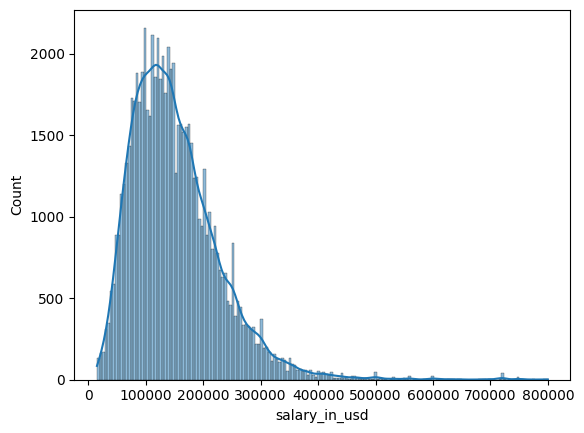

In [ ]:
sns.histplot(df["salary_in_usd"], kde=True)

In [ ]:
y = np.log(df["salary_in_usd"])

<Axes: xlabel='salary_in_usd', ylabel='Count'>

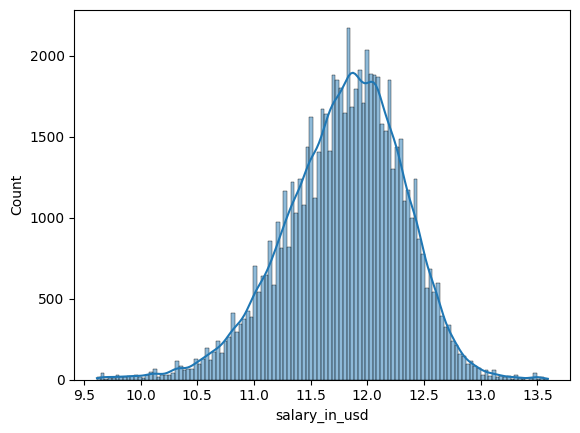

In [ ]:
sns.histplot(y, kde=True)

<Axes: xlabel='experience_level', ylabel='salary_in_usd'>

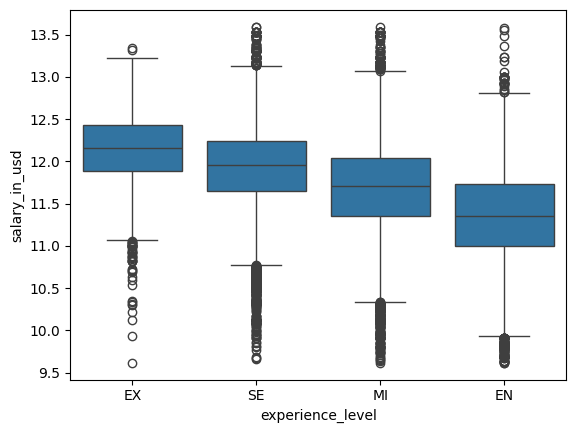

In [ ]:

sns.boxplot(x="experience_level", y=y, data=df)

<Axes: xlabel='experience_level', ylabel='salary_in_usd'>

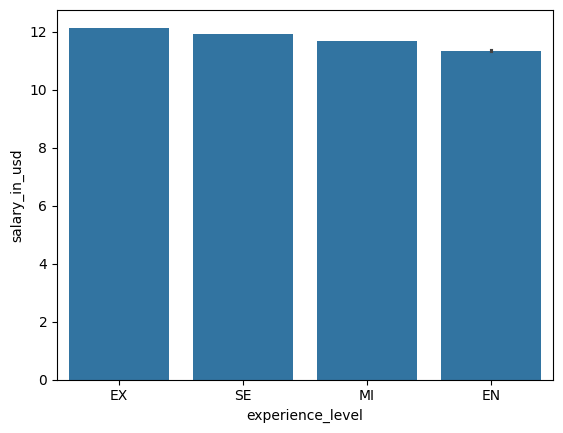

In [ ]:
sns.barplot(x="experience_level", y=y, data=df)

In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

<Axes: xlabel='work_year', ylabel='salary_in_usd'>

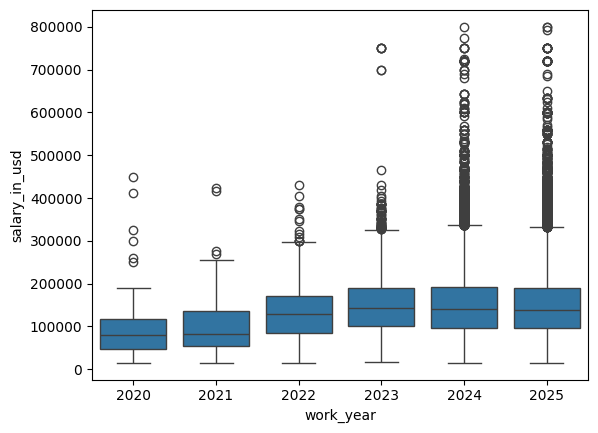

In [ ]:
sns.boxplot(x="work_year", y="salary_in_usd", data=df)

<Axes: xlabel='company_size', ylabel='salary_in_usd'>

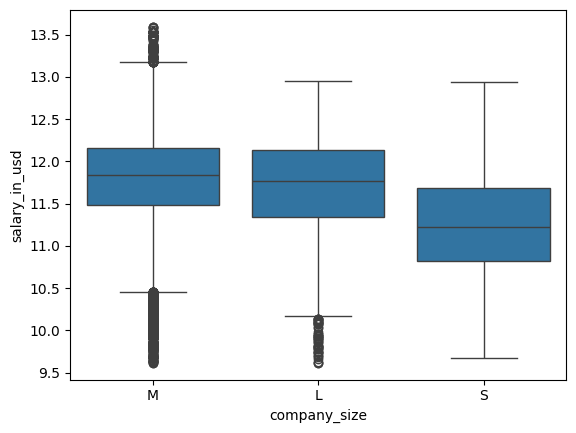

In [ ]:
sns.boxplot(x="company_size", y=y, data=df)

<Axes: xlabel='employment_type', ylabel='salary_in_usd'>

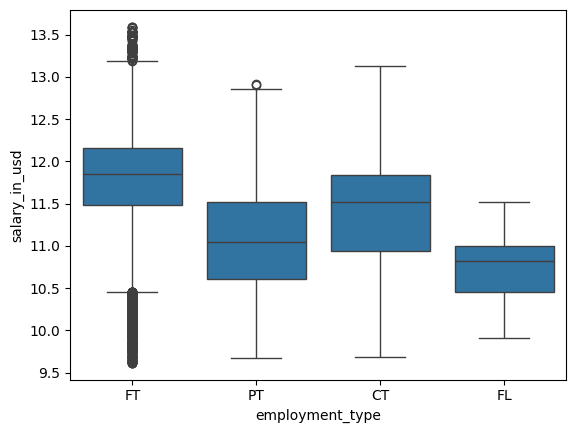

In [ ]:
sns.boxplot(x="employment_type", y=y, data=df)

<Axes: xlabel='company_size', ylabel='salary_in_usd'>

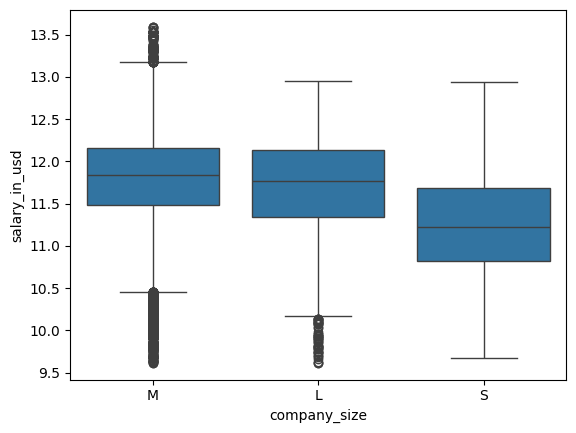

In [ ]:
sns.boxplot(x="company_size", y=y, data=df)

### 1st Approach

MSE: 4536557028.644332
MAE: 47157.462401886994
R2: 0.25042524967741453


In [ ]:
top_10_company_locations = df['company_location'].value_counts().nlargest(10).index
df['company_location'] = df['company_location'].apply(lambda x: x if x in top_10_company_locations else 'Other')
df['company_location'].value_counts()

,count
company_location,
US,60147
CA,4571
GB,2835
Other,2007
AU,511
DE,400
NL,398
LT,312
FR,302


In [ ]:
top_10_employee_residence = df['employee_residence'].value_counts().nlargest(10).index
df['employee_residence'] = df['employee_residence'].apply(lambda x: x if x in top_10_employee_residence else 'other')
df['employee_residence'].value_counts()

,count
employee_residence,
US,60085
CA,4570
GB,2826
other,2062
AU,506
NL,398
DE,390
LT,312
FR,306


In [ ]:
top_15_job_titles = df['job_title'].value_counts().nlargest(45).index
df['job_title'] = df['job_title'].apply(lambda x: x if x in top_15_job_titles else 'other')
df['job_title'].value_counts()

,count
job_title,
other,10881
Data Scientist,7160
Data Engineer,7071
Data Analyst,6405
Software Engineer,4921
Engineer,4375
Manager,3612
Machine Learning Engineer,3462
Analyst,2783


In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,US,100,US,M


In [ ]:
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numerical_features = ['work_year', 'remote_ratio']
ordinal_features = ['experience_level', 'company_size']
nominal_features = ['employee_residence', 'company_location', 'job_title','employment_type']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        ['EN', 'MI', 'SE', 'EX'],   # experience_level
        ['S', 'M', 'L']             # company_size
    ]))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)

    ],

)



In [ ]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['work_year',
                                                   'remote_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['employee_residence',
                                                   'company_location',
                                                   'job_title',
                                                   'employment_type']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['EN',
                                                                                               'MI',
                                                                                               'SE',
                                                                                               'EX'],
                                                                                              ['S',
                                                                                               'M',
                                                                                               'L']]))]),
                                                  ['experience_level',
                                                   'company_size'])])),
                ('regressor', LinearRegression())])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# y_pred = model.predict(X_test)

# print("MSE:", mean_squared_error(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("R2:", r2_score(y_test, y_pred))

MSE: 4438751683.240762
MAE: 48199.73181239623
R2: 0.26658561466306163


In [ ]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model.fit(X_train, y_train_log)

y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 4575282448.07237
MAE: 46996.604512659396
R2: 0.24402665346984442


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor



model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
                    n_estimators=100,
                    max_depth=None,
                    random_state=42
                ))
])

model.fit(X_train, y_train_log)

y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 4536557028.644332
MAE: 47157.462401886994
R2: 0.25042524967741453


### 2nd Approach

MSE: 0.1883240913976241
MAE: 0.34343276541331663
R2: 0.30885446553026663

In [57]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size'],
      dtype='object')

In [87]:
X = df.drop('salary_in_usd', axis=1)
y = np.log(df['salary_in_usd'])

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = ['work_year', 'remote_ratio']
ordinal_features = ['experience_level', 'company_size']
nominal_features = ['company_location','employment_type','employee_residence']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        ['EN', 'MI', 'SE', 'EX'],   # experience_level
        ['S', 'M', 'L']             # company_size
    ]))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)

    ],

)

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor


model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression Evalueation:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Linear Regression Evalueation:
MSE: 0.18981366075386621
MAE: 0.345250164069805
R2: 0.3033877766897187


In [63]:

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
                    n_estimators=100,
                    max_depth=None,
                    random_state=42
                ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest Evalueation:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Random Forest Evalueation:
MSE: 0.1883240913976241
MAE: 0.34343276541331663
R2: 0.30885446553026663


### Approach III

RF
MSE: 0.16481309549292086
MAE: 0.3203971091514622
R2: 0.3951393359888362


In [187]:
engineer_job_titles = df[df['job_title'].str.contains('Research Engineer')]['job_title'].unique()
display(engineer_job_titles)



array(['Research Engineer', 'AI Research Engineer',
       'Machine Learning Research Engineer'], dtype=object)

In [188]:
engineer_job_titles = df[df['job_title'].str.contains('Analytics Engineer')]['job_title'].unique()
display(engineer_job_titles)

array(['Analytics Engineer', 'Analytics Engineering Manager',
       'Data Analytics Engineer'], dtype=object)

In [200]:
df['Is_Lead'] = df['job_title'].apply(lambda x: 1 if 'lead' in x.lower() else 0)
df['Is_Head'] = df['job_title'].apply(lambda x: 1 if 'head' in x.lower() else 0)
df['Is_manager'] = df['job_title'].apply(lambda x: 1 if 'manager' in x.lower() else 0)
df['Is_director'] = df['job_title'].apply(lambda x: 1 if 'director' in x.lower() else 0)
df['Is_Principal'] = df['job_title'].apply(lambda x: 1 if 'principal' in x.lower() else 0)

In [190]:
display(df[['job_title', 'Is_Lead', 'Is_manager', 'Is_director', 'Is_Principal']].head())

,job_title,Is_Lead,Is_manager,Is_director,Is_Principal
0,Head of Data,0,0,0,0
1,Head of Data,0,0,0,0
2,Data Scientist,0,0,0,0
3,Data Scientist,0,0,0,0
4,Engineer,0,0,0,0


In [201]:
def get_job_category(job_title):
    job_title = job_title.lower()

    if 'associate' in job_title:
        return 'Associate'

    # if 'machine learning' in job_title or 'ml' in job_title:
    #     return 'ML_Engineer'

    if 'consultant' in job_title:
        if 'data' in job_title:
            return 'Data_Consultant'
        else:
            return 'Other_Consultant'

    if 'architect' in job_title:
        if 'data' in job_title:
            return 'Data_Architect'
        elif 'ai' in job_title:
            return 'AI_Architect'
        else:
            return 'Other_Architect'


    if 'manager' in job_title:
        if 'data' in job_title:
            return 'Data_Manager'
        else:
            return 'Other_Manager' # Generic Manager role

    # Prioritize Scientist roles
    if 'scientist' in job_title:
        if 'data' in job_title:
            return 'Data_Scientist'
        elif 'research' in job_title:
            return 'Research_Scientist'
        else:
            return 'Other_Scientist' # Generic Scientist role

    # Prioritize Analyst roles
    if 'analyst' in job_title:
        if 'data' in job_title:
            return 'Data_Analyst'
        elif 'bi' in job_title:
            return 'BI_Analyst'
        else:
            return 'Other_Analyst' # Generic Analyst role

    # Then Engineer roles (from previous iteration)
    if 'engineer' in job_title:
        if 'data' in job_title:
            return 'Data_Engineer'
        elif 'machine learning' in job_title or 'ml' in job_title:
            return 'ML_Engineer'
        elif 'ai' in job_title or 'artificial intelligence' in job_title:
            return 'AI_Engineer'
        elif 'software' in job_title:
            return 'Software_Engineer'
        # elif 'engineer' in job_title:
        #     return 'Engineer'
        elif ' engineer' in job_title or 'engineer 'in job_title:
            return 'Other_Engineer' # Generic Engineer role
        else:
            return 'Engineer'

    # Other broad categories that don't fit above more specific roles
    if 'ai' in job_title or 'artificial intelligence' in job_title:
        return 'Other_AI_Role' # e.g., AI Specialist not an engineer

    if 'data' in job_title:
        return 'Other_Data_Role' # e.g., Data Manager, Data Lead not scientist, analyst, or engineer

    if 'software' in job_title:
        return 'Other_Software_Role' # e.g., Software Developer not an engineer

    return 'Other_Category' # Default for anything not matched

df['job_category'] = df['job_title'].apply(get_job_category)

In [202]:
df[df['job_category'] == 'Other_Engineer']['job_title'].value_counts().head(20)

,count
job_title,
Analytics Engineer,1341
Research Engineer,887
Systems Engineer,563
Platform Engineer,411
Business Intelligence Engineer,397
DevOps Engineer,382
Site Reliability Engineer,333
Solutions Engineer,277
Backend Engineer,248


In [203]:
print(df['job_category'].value_counts())


job_category
Data_Engineer          7610
Data_Analyst           7306
Data_Scientist         7213
Other_Engineer         6203
Other_Manager          5579
Software_Engineer      5348
Other_Category         5025
Other_Analyst          4515
Engineer               4375
ML_Engineer            3749
Other_Data_Role        3359
Associate              1461
Research_Scientist     1391
Other_Architect        1345
Other_Scientist        1343
Data_Manager           1278
Data_Architect         1239
AI_Engineer            1227
Other_Consultant        791
Other_AI_Role           544
Other_Software_Role     525
AI_Architect            229
BI_Analyst              182
Data_Consultant          76
Name: count, dtype: int64


In [204]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,Is_Lead,Is_manager,Is_director,Is_Principal,job_category,Is_Head
0,2025,EX,FT,Head of Data,348516,US,0,US,M,0,0,0,0,Other_Data_Role,1
1,2025,EX,FT,Head of Data,232344,US,0,US,M,0,0,0,0,Other_Data_Role,1
2,2025,SE,FT,Data Scientist,145400,US,0,US,M,0,0,0,0,Data_Scientist,0
3,2025,SE,FT,Data Scientist,81600,US,0,US,M,0,0,0,0,Data_Scientist,0
4,2025,MI,FT,Engineer,160000,US,100,US,M,0,0,0,0,Engineer,0


In [205]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size', 'Is_Lead', 'Is_manager',
       'Is_director', 'Is_Principal', 'job_category', 'Is_Head'],
      dtype='object')

In [206]:
X = df.drop('salary_in_usd', axis=1)
y = np.log(df['salary_in_usd'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [207]:
numerical_features = ['work_year', 'remote_ratio', 'Is_Lead', 'Is_Head','Is_manager', 'Is_director', 'Is_Principal']
ordinal_features = ['experience_level', 'company_size']
nominal_features = ['company_location','employee_residence' ,'job_category','employment_type']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        ['EN', 'MI', 'SE', 'EX'],   # experience_level
        ['S', 'M', 'L']             # company_size
    ]))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)

    ],

)

In [208]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Linear Regression Evalueation:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Linear Regression Evalueation:
MSE: 0.16729518749213007
MAE: 0.3224407682779458
R2: 0.3860301095023828


In [209]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
                    n_estimators=100,
                    max_depth=None,
                    random_state=42
                ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest Evalueation:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Random Forest Evalueation:
MSE: 0.16481309549292086
MAE: 0.3203971091514622
R2: 0.3951393359888362
